<div align="center">

# **Tugas Besar ASA 2026**

## **Perbandingan Algoritma Dynamic Programming, Divide and Conquer, dan Moore dalam Minimasi Deterministic Finite Automaton untuk Mengelompokkan State Ekuivalen**

<br><br>

### Oleh

**Jordan Tenggara**  
**[redacted]**  
**[redacted]**

<br> <br>
## **Departemen Informatika**
## **Universitas Diponegoro**
## **2026**


</div>

# Tahap 1: Inisialisasi DFA

## 1. Import Library Awal

In [ ]:
import json
from dataclasses import dataclass
from typing import Dict, List, Set, Tuple

## 2. Membuat Class DFA

In [ ]:
@dataclass
class DFA:
    name: str
    states: Set[str]
    alphabet: Set[str]
    transitions: Dict[Tuple[str, str], str]
    start_state: str
    accept_states: Set[str]

    def summary(self):
        """
        Menampilkan ringkasan DFA.
        Fungsi ini berguna untuk mengecek isi DFA setelah dibaca dari file.
        """
        print(f"Nama DFA       : {self.name}")
        print(f"Jumlah State   : {len(self.states)}")
        print(f"States         : {sorted(self.states)}")
        print(f"Alphabet       : {sorted(self.alphabet)}")
        print(f"Start State    : {self.start_state}")
        print(f"Accept States  : {sorted(self.accept_states)}")
        print(f"Jumlah Transisi: {len(self.transitions)}")

    def show_transitions(self):
        """
        Menampilkan semua transisi DFA dalam bentuk rapi.
        """
        print(f"Transisi untuk {self.name}:")
        for state in sorted(self.states):
            for symbol in sorted(self.alphabet):
                target = self.transitions.get((state, symbol))
                print(f"δ({state}, {symbol}) = {target}")

## 3. Validasi Struktur DFA

In [ ]:
def validate_dfa(dfa: DFA) -> bool:
    """
    Memvalidasi apakah sebuah DFA sudah memenuhi syarat formal.

    Syarat DFA valid:
    1. start_state harus ada di states
    2. accept_states harus subset dari states
    3. setiap state harus memiliki transisi untuk setiap simbol alphabet
    4. setiap target transisi harus menuju state yang valid
    """

    errors = []
    if dfa.start_state not in dfa.states:
        errors.append(f"Start state '{dfa.start_state}' tidak ada dalam daftar states.")

    invalid_accept_states = dfa.accept_states - dfa.states
    if invalid_accept_states:
        errors.append(f"Accept states tidak valid: {invalid_accept_states}")

    for state in dfa.states:
        for symbol in dfa.alphabet:
            if (state, symbol) not in dfa.transitions:
                errors.append(f"Transisi hilang: δ({state}, {symbol}) belum didefinisikan.")

    for (source_state, symbol), target_state in dfa.transitions.items():

        if source_state not in dfa.states:
            errors.append(f"Source state '{source_state}' pada transisi tidak ada dalam states.")

        if symbol not in dfa.alphabet:
            errors.append(f"Simbol '{symbol}' pada transisi tidak ada dalam alphabet.")

        if target_state not in dfa.states:
            errors.append(f"Target state '{target_state}' tidak ada dalam states.")

    if errors:
        print(f"DFA '{dfa.name}' tidak valid.")
        for error in errors:
            print("-", error)
        return False

    print(f"DFA '{dfa.name}' valid.")
    return True

## 4. Parsing Format Transisi JSON

In [ ]:
def parse_transitions(json_transitions: Dict[str, str]) -> Dict[Tuple[str, str], str]:
    """
    Mengubah format transisi dari JSON menjadi format Python.

    Dari:
        "q0,0": "q1"

    Menjadi:
        ("q0", "0"): "q1"
    """

    transitions = {}

    for key, target_state in json_transitions.items():
        try:
            source_state, symbol = key.split(",", 1)
        except ValueError:
            raise ValueError(
                f"Format transisi '{key}' salah. Gunakan format 'state,symbol', contoh: 'q0,0'."
            )

        source_state = source_state.strip()
        symbol = symbol.strip()
        target_state = target_state.strip()

        transitions[(source_state, symbol)] = target_state

    return transitions

## 5. Loader Dataset DFA dari JSON

In [ ]:
def load_dfas_from_json(file_path: str) -> List[DFA]:
    """
    Membaca file JSON yang berisi banyak DFA.
    Output berupa list object DFA.
    """

    with open(file_path, "r") as file:
        data = json.load(file)

    if "dfas" not in data:
        raise ValueError("File JSON harus memiliki key utama 'dfas'.")

    dfa_list = []

    for dfa_data in data["dfas"]:
        name = dfa_data["name"]
        states = set(dfa_data["states"])
        alphabet = set(dfa_data["alphabet"])
        transitions = parse_transitions(dfa_data["transitions"])
        start_state = dfa_data["start_state"]
        accept_states = set(dfa_data["accept_states"])

        dfa = DFA(
            name=name,
            states=states,
            alphabet=alphabet,
            transitions=transitions,
            start_state=start_state,
            accept_states=accept_states
        )

        is_valid = validate_dfa(dfa)

        if not is_valid:
            raise ValueError(f"DFA '{name}' tidak valid. Perbaiki file JSON terlebih dahulu.")

        dfa_list.append(dfa)

    return dfa_list

## 6. Contoh Dataset DFA

In [ ]:
sample_dataset = {
    "dfas": [
        {
            "name": "DFA_Redundant_States",
            "states": ["q0", "q1", "q2", "q3"],
            "alphabet": ["0", "1"],
            "start_state": "q0",
            "accept_states": ["q3"],
            "transitions": {
                "q0,0": "q1",
                "q0,1": "q2",
                "q1,0": "q3",
                "q1,1": "q3",
                "q2,0": "q3",
                "q2,1": "q3",
                "q3,0": "q3",
                "q3,1": "q3"
            }
        },
        {
            "name": "DFA_Even_Number_of_Zeros",
            "states": ["A", "B"],
            "alphabet": ["0", "1"],
            "start_state": "A",
            "accept_states": ["A"],
            "transitions": {
                "A,0": "B",
                "A,1": "A",
                "B,0": "A",
                "B,1": "B"
            }
        }
    ]
}

file_name = "dfa_dataset_sample.json"

with open(file_name, "w") as file:
    json.dump(sample_dataset, file, indent=4)

print(f"File '{file_name}' berhasil dibuat.")

File 'dfa_dataset_sample.json' berhasil dibuat.


## 7. Membaca Contoh Dataset

In [ ]:
dfas = load_dfas_from_json("dfa_dataset_sample.json")

print(f"\nJumlah DFA berhasil dibaca: {len(dfas)}")

DFA 'DFA_Redundant_States' valid.
DFA 'DFA_Even_Number_of_Zeros' valid.

Jumlah DFA berhasil dibaca: 2


## 8. Menampilkan Informasi DFA

In [ ]:
for dfa in dfas:
    print("=" * 50)
    dfa.summary()

Nama DFA       : DFA_Redundant_States
Jumlah State   : 4
States         : ['q0', 'q1', 'q2', 'q3']
Alphabet       : ['0', '1']
Start State    : q0
Accept States  : ['q3']
Jumlah Transisi: 8
Nama DFA       : DFA_Even_Number_of_Zeros
Jumlah State   : 2
States         : ['A', 'B']
Alphabet       : ['0', '1']
Start State    : A
Accept States  : ['A']
Jumlah Transisi: 4


## 9. Menampilkan Transisi DFA

In [ ]:
dfas[0].show_transitions()

Transisi untuk DFA_Redundant_States:
δ(q0, 0) = q1
δ(q0, 1) = q2
δ(q1, 0) = q3
δ(q1, 1) = q3
δ(q2, 0) = q3
δ(q2, 1) = q3
δ(q3, 0) = q3
δ(q3, 1) = q3


## 10. Upload & Baca Input Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

dfas = load_dfas_from_json("dfa_dataset_augmented.json")

print(f"Jumlah DFA berhasil dibaca: {len(dfas)}")

Saving dfa_dataset_augmented.json to dfa_dataset_augmented (1).json
DFA 'DFA_01_Redundant_4_State' valid.
DFA 'DFA_02_Even_Number_of_Zeros' valid.
DFA 'DFA_03_All_NonFinal_Equivalent' valid.
DFA 'DFA_04_Sink_State_With_Redundancy' valid.
DFA 'DFA_05_Duplicate_Final_States' valid.
DFA 'DFA_06_Ends_With_01_Expanded' valid.
DFA 'DFA_07_Modulo_3_Expanded' valid.
DFA 'DFA_08_Two_Equivalent_Blocks' valid.
DFA 'DFA_09_Larger_Redundant_10_State' valid.
DFA 'DFA_10_Binary_Parity_Expanded' valid.
DFA 'DFA_11_Three_Class_12_State' valid.
DFA 'DFA_12_Mixed_14_State' valid.
DFA 'DFA_13_Tiny_Minimal_2_State' valid.
DFA 'DFA_14_Large_Two_Block_20_State' valid.
DFA 'DFA_15_Long_Chain_20_State' valid.
DFA 'DFA_16_Large_Two_Block_50_State' valid.
Jumlah DFA berhasil dibaca: 16


# Tahap 2: Algoritma Moore


## 11. Library Tambahan Khusus Algoritma Moore

In [ ]:
from collections import defaultdict

## 12. Fungsi Partisi

In [ ]:
def normalize_partition(partition):
    """
    Merapikan format partisi agar mudah dibandingkan dan ditampilkan.

    Input:
        partition = [set(...), set(...), ...]

    Output:
        list of set yang sudah diurutkan berdasarkan nama state terkecil.
    """

    cleaned_partition = [set(group) for group in partition if len(group) > 0]

    normalized = sorted(
        cleaned_partition,
        key=lambda group: sorted(group)[0]
    )

    return normalized


def print_partition(partition, title="Kelompok State Ekuivalen"):
    """
    Menampilkan hasil partisi state dalam format rapi.
    """

    print(title)
    print("-" * len(title))

    for i, group in enumerate(partition, start=1):
        print(f"Kelompok {i}: {sorted(group)}")

    print(f"\nJumlah kelompok/state hasil minimisasi: {len(partition)}")

## 13. Implementasi Algoritma Moore

In [ ]:
def moore_minimization(dfa, verbose=False):
    """
    Melakukan minimisasi DFA menggunakan Algoritma Moore.

    Ide utama:
    1. Awalnya state dibagi menjadi dua kelompok:
       - accepting states
       - non-accepting states

    2. Setiap iterasi, setiap kelompok akan dipecah lagi berdasarkan
       signature transisi masing-masing state.

    3. Proses berhenti ketika partisi sudah stabil,
       yaitu tidak ada kelompok yang berubah lagi.

    Parameter:
        dfa     : object DFA
        verbose : jika True, tampilkan proses iterasi

    Output:
        partition : list of set
                    kelompok state ekuivalen hasil minimisasi
    """

    if not validate_dfa(dfa):
        raise ValueError(f"DFA '{dfa.name}' tidak valid sehingga tidak bisa diminimalkan.")

    alphabet = sorted(dfa.alphabet)

    accepting_group = set(dfa.accept_states)
    non_accepting_group = set(dfa.states) - set(dfa.accept_states)

    partition = normalize_partition([accepting_group, non_accepting_group])

    if verbose:
        print(f"\nPartisi awal untuk {dfa.name}:")
        print_partition(partition, "Partisi Awal")

    iteration = 0

    while True:
        iteration += 1

        state_to_group = {}

        for group_index, group in enumerate(partition):
            for state in group:
                state_to_group[state] = group_index

        new_partition = []

        for group in partition:
            buckets = defaultdict(set)

            for state in group:
                signature = tuple(
                    state_to_group[dfa.transitions[(state, symbol)]]
                    for symbol in alphabet
                )

                buckets[signature].add(state)

            for bucket in buckets.values():
                new_partition.append(bucket)

        new_partition = normalize_partition(new_partition)

        if verbose:
            print(f"\nIterasi {iteration}:")
            print_partition(new_partition, f"Partisi Setelah Iterasi {iteration}")

        if new_partition == partition:
            break

        partition = new_partition

    return partition

## 14. Pengujian Algoritma Moore pada satu DFA

In [ ]:
dfa_test = dfas[0]

dfa_test.summary()
dfa_test.show_transitions()

moore_result = moore_minimization(dfa_test, verbose=True)

print("\nHasil Akhir Moore:")
print_partition(moore_result)

Nama DFA       : DFA_01_Redundant_4_State
Jumlah State   : 4
States         : ['q0', 'q1', 'q2', 'q3']
Alphabet       : ['0', '1']
Start State    : q0
Accept States  : ['q3']
Jumlah Transisi: 8
Transisi untuk DFA_01_Redundant_4_State:
δ(q0, 0) = q1
δ(q0, 1) = q2
δ(q1, 0) = q3
δ(q1, 1) = q3
δ(q2, 0) = q3
δ(q2, 1) = q3
δ(q3, 0) = q3
δ(q3, 1) = q3
DFA 'DFA_01_Redundant_4_State' valid.

Partisi awal untuk DFA_01_Redundant_4_State:
Partisi Awal
------------
Kelompok 1: ['q0', 'q1', 'q2']
Kelompok 2: ['q3']

Jumlah kelompok/state hasil minimisasi: 2

Iterasi 1:
Partisi Setelah Iterasi 1
-------------------------
Kelompok 1: ['q0']
Kelompok 2: ['q1', 'q2']
Kelompok 3: ['q3']

Jumlah kelompok/state hasil minimisasi: 3

Iterasi 2:
Partisi Setelah Iterasi 2
-------------------------
Kelompok 1: ['q0']
Kelompok 2: ['q1', 'q2']
Kelompok 3: ['q3']

Jumlah kelompok/state hasil minimisasi: 3

Hasil Akhir Moore:
Kelompok State Ekuivalen
------------------------
Kelompok 1: ['q0']
Kelompok 2: ['q1', 'q

## 15. Pengujian Moore pada Semua DFA

In [ ]:
for dfa in dfas:
    print("=" * 60)
    print(f"Moore Minimization untuk: {dfa.name}")
    print(f"Jumlah state awal: {len(dfa.states)}")

    result = moore_minimization(dfa, verbose=False)

    print_partition(result, "Hasil Kelompok State Ekuivalen")

Moore Minimization untuk: DFA_01_Redundant_4_State
Jumlah state awal: 4
DFA 'DFA_01_Redundant_4_State' valid.
Hasil Kelompok State Ekuivalen
------------------------------
Kelompok 1: ['q0']
Kelompok 2: ['q1', 'q2']
Kelompok 3: ['q3']

Jumlah kelompok/state hasil minimisasi: 3
Moore Minimization untuk: DFA_02_Even_Number_of_Zeros
Jumlah state awal: 2
DFA 'DFA_02_Even_Number_of_Zeros' valid.
Hasil Kelompok State Ekuivalen
------------------------------
Kelompok 1: ['A']
Kelompok 2: ['B']

Jumlah kelompok/state hasil minimisasi: 2
Moore Minimization untuk: DFA_03_All_NonFinal_Equivalent
Jumlah state awal: 5
DFA 'DFA_03_All_NonFinal_Equivalent' valid.
Hasil Kelompok State Ekuivalen
------------------------------
Kelompok 1: ['s0', 's1', 's2', 's3', 's4']

Jumlah kelompok/state hasil minimisasi: 1
Moore Minimization untuk: DFA_04_Sink_State_With_Redundancy
Jumlah state awal: 6
DFA 'DFA_04_Sink_State_With_Redundancy' valid.
Hasil Kelompok State Ekuivalen
------------------------------
Kelom

# Tahap 3: Dynamic Programming


## 16. Import Fungsi Kombinasi

In [ ]:
from itertools import combinations

## 17. Fungsi Pembentuk Pasangan State

In [ ]:
def make_pair(state1, state2):
    """
    Membuat pasangan state dalam urutan konsisten.

    Tujuan:
    agar pasangan (q1, q2) dan (q2, q1) dianggap sama.
    """

    return tuple(sorted([state1, state2]))

## 18. Struktur Data Union Find

In [ ]:
class UnionFind:
    """
    Struktur data Union-Find digunakan untuk menggabungkan state-state
    yang ekuivalen ke dalam kelompok yang sama.
    """

    def __init__(self, elements):
        self.parent = {element: element for element in elements}

    def find(self, element):
        """
        Mencari root dari suatu elemen.
        Menggunakan path compression agar lebih efisien.
        """

        if self.parent[element] != element:
            self.parent[element] = self.find(self.parent[element])

        return self.parent[element]

    def union(self, element1, element2):
        """
        Menggabungkan dua elemen ke dalam kelompok yang sama.
        """

        root1 = self.find(element1)
        root2 = self.find(element2)

        if root1 != root2:
            self.parent[root2] = root1

    def get_groups(self):
        """
        Menghasilkan kelompok akhir berdasarkan root masing-masing elemen.
        """

        groups = {}

        for element in self.parent:
            root = self.find(element)

            if root not in groups:
                groups[root] = set()

            groups[root].add(element)

        return list(groups.values())

## 19. Implementasi Dynamic Programming

In [ ]:
def dp_minimization(dfa, verbose=False):
    """
    Mengelompokkan state ekuivalen pada DFA menggunakan pendekatan Dynamic Programming.

    Ide utama:
    1. Buat tabel memo untuk semua pasangan state.
    2. Pasangan state yang satu final dan satu non-final langsung ditandai berbeda.
    3. Untuk pasangan lain, cek transisi keduanya.
    4. Jika transisi menuju pasangan yang sudah diketahui berbeda,
       maka pasangan saat ini juga berbeda.
    5. Proses diulang sampai tidak ada perubahan.
    6. Pasangan yang tidak ditandai berbeda dianggap ekuivalen.

    Output:
        partition : list of set
                    kelompok state ekuivalen
    """

    if not validate_dfa(dfa):
        raise ValueError(f"DFA '{dfa.name}' tidak valid sehingga tidak bisa diproses.")

    states = sorted(dfa.states)
    alphabet = sorted(dfa.alphabet)

    memo = {}

    for state1, state2 in combinations(states, 2):
        pair = make_pair(state1, state2)

        state1_is_final = state1 in dfa.accept_states
        state2_is_final = state2 in dfa.accept_states

        if state1_is_final != state2_is_final:
            memo[pair] = True
        else:
            memo[pair] = False

    if verbose:
        print("Tabel awal pasangan state:")
        for pair, is_different in memo.items():
            status = "Berbeda" if is_different else "Belum berbeda"
            print(f"{pair}: {status}")

    changed = True
    iteration = 0

    while changed:
        changed = False
        iteration += 1

        if verbose:
            print(f"\nIterasi DP ke-{iteration}")

        for state1, state2 in combinations(states, 2):
            pair = make_pair(state1, state2)

            if memo[pair] is True:
                continue

            for symbol in alphabet:
                next_state1 = dfa.transitions[(state1, symbol)]
                next_state2 = dfa.transitions[(state2, symbol)]

                if next_state1 == next_state2:
                    continue

                next_pair = make_pair(next_state1, next_state2)

                if memo.get(next_pair, False) is True:
                    memo[pair] = True
                    changed = True

                    if verbose:
                        print(
                            f"{pair} ditandai berbeda karena "
                            f"δ({state1}, {symbol})={next_state1} dan "
                            f"δ({state2}, {symbol})={next_state2} "
                            f"menuju pasangan berbeda {next_pair}"
                        )

                    break

    uf = UnionFind(states)

    for state1, state2 in combinations(states, 2):
        pair = make_pair(state1, state2)

        if memo[pair] is False:
            uf.union(state1, state2)

    partition = normalize_partition(uf.get_groups())

    if verbose:
        print("\nTabel akhir pasangan state:")
        for pair, is_different in memo.items():
            status = "Berbeda" if is_different else "Ekuivalen"
            print(f"{pair}: {status}")

    return partition, memo

## 20. Pengujian Dynamic Programming pada Satu DFA

In [ ]:
dfa_test = dfas[0]

print("=" * 60)
print("DFA yang diuji dengan Dynamic Programming:")
dfa_test.summary()

dp_result, dp_memo = dp_minimization(dfa_test, verbose=True)

print("\nHasil Akhir Dynamic Programming:")
print_partition(dp_result)

DFA yang diuji dengan Dynamic Programming:
Nama DFA       : DFA_01_Redundant_4_State
Jumlah State   : 4
States         : ['q0', 'q1', 'q2', 'q3']
Alphabet       : ['0', '1']
Start State    : q0
Accept States  : ['q3']
Jumlah Transisi: 8
DFA 'DFA_01_Redundant_4_State' valid.
Tabel awal pasangan state:
('q0', 'q1'): Belum berbeda
('q0', 'q2'): Belum berbeda
('q0', 'q3'): Berbeda
('q1', 'q2'): Belum berbeda
('q1', 'q3'): Berbeda
('q2', 'q3'): Berbeda

Iterasi DP ke-1
('q0', 'q1') ditandai berbeda karena δ(q0, 0)=q1 dan δ(q1, 0)=q3 menuju pasangan berbeda ('q1', 'q3')
('q0', 'q2') ditandai berbeda karena δ(q0, 0)=q1 dan δ(q2, 0)=q3 menuju pasangan berbeda ('q1', 'q3')

Iterasi DP ke-2

Tabel akhir pasangan state:
('q0', 'q1'): Berbeda
('q0', 'q2'): Berbeda
('q0', 'q3'): Berbeda
('q1', 'q2'): Ekuivalen
('q1', 'q3'): Berbeda
('q2', 'q3'): Berbeda

Hasil Akhir Dynamic Programming:
Kelompok State Ekuivalen
------------------------
Kelompok 1: ['q0']
Kelompok 2: ['q1', 'q2']
Kelompok 3: ['q3']


## 21. Fungsi Perbandingan Moore dengan Dynamic Programming

In [ ]:
def partition_to_frozenset(partition):
    """
    Mengubah partition menjadi set of frozenset agar mudah dibandingkan.
    """

    return set(frozenset(group) for group in partition)


def compare_with_moore(dfa, verbose=False):
    """
    Membandingkan hasil Dynamic Programming dengan hasil Moore.

    Output:
        dictionary berisi hasil Moore, hasil DP, dan status kesamaan.
    """

    moore_result = moore_minimization(dfa, verbose=False)
    dp_result, dp_memo = dp_minimization(dfa, verbose=False)

    moore_set = partition_to_frozenset(moore_result)
    dp_set = partition_to_frozenset(dp_result)

    is_same = moore_set == dp_set

    if verbose:
        print("=" * 60)
        print(f"Perbandingan Moore vs Dynamic Programming untuk {dfa.name}")
        print("=" * 60)

        print("\nHasil Moore:")
        print_partition(moore_result)

        print("\nHasil Dynamic Programming:")
        print_partition(dp_result)

        if is_same:
            print("\nStatus: HASIL SAMA")
        else:
            print("\nStatus: HASIL BERBEDA")

    return {
        "dfa_name": dfa.name,
        "moore_partition": moore_result,
        "dp_partition": dp_result,
        "same_result": is_same
    }

22. Uji Perbandingan Moore dengan Dynamic Programming pada Satu DFA

In [ ]:
comparison_result = compare_with_moore(dfas[0], verbose=True)

DFA 'DFA_01_Redundant_4_State' valid.
DFA 'DFA_01_Redundant_4_State' valid.
Perbandingan Moore vs Dynamic Programming untuk DFA_01_Redundant_4_State

Hasil Moore:
Kelompok State Ekuivalen
------------------------
Kelompok 1: ['q0']
Kelompok 2: ['q1', 'q2']
Kelompok 3: ['q3']

Jumlah kelompok/state hasil minimisasi: 3

Hasil Dynamic Programming:
Kelompok State Ekuivalen
------------------------
Kelompok 1: ['q0']
Kelompok 2: ['q1', 'q2']
Kelompok 3: ['q3']

Jumlah kelompok/state hasil minimisasi: 3

Status: HASIL SAMA


## 23. Uji Perbandingan Moore dengan Dynamic Programming pada Semua DFA

In [ ]:
for dfa in dfas:
    comparison = compare_with_moore(dfa, verbose=True)

DFA 'DFA_01_Redundant_4_State' valid.
DFA 'DFA_01_Redundant_4_State' valid.
Perbandingan Moore vs Dynamic Programming untuk DFA_01_Redundant_4_State

Hasil Moore:
Kelompok State Ekuivalen
------------------------
Kelompok 1: ['q0']
Kelompok 2: ['q1', 'q2']
Kelompok 3: ['q3']

Jumlah kelompok/state hasil minimisasi: 3

Hasil Dynamic Programming:
Kelompok State Ekuivalen
------------------------
Kelompok 1: ['q0']
Kelompok 2: ['q1', 'q2']
Kelompok 3: ['q3']

Jumlah kelompok/state hasil minimisasi: 3

Status: HASIL SAMA
DFA 'DFA_02_Even_Number_of_Zeros' valid.
DFA 'DFA_02_Even_Number_of_Zeros' valid.
Perbandingan Moore vs Dynamic Programming untuk DFA_02_Even_Number_of_Zeros

Hasil Moore:
Kelompok State Ekuivalen
------------------------
Kelompok 1: ['A']
Kelompok 2: ['B']

Jumlah kelompok/state hasil minimisasi: 2

Hasil Dynamic Programming:
Kelompok State Ekuivalen
------------------------
Kelompok 1: ['A']
Kelompok 2: ['B']

Jumlah kelompok/state hasil minimisasi: 2

Status: HASIL SAMA

# Tahap 4: Divide and Conquer



## 24. Fungsi Rekursif Pemeriksaan Ekuivalensi State

In [ ]:
def are_equivalent_recursive(dfa, state1, state2, memo=None, visiting=None):
    """
    Mengecek apakah dua state ekuivalen menggunakan pendekatan rekursif
    dengan memoization.

    Fungsi ini digunakan sebagai equivalence checker pada proses
    Divide and Conquer.

    Parameter:
        dfa      : object DFA
        state1   : state pertama
        state2   : state kedua
        memo     : penyimpanan hasil pengecekan pasangan state
        visiting : pasangan state yang sedang dikunjungi untuk menangani siklus

    Output:
        True  -> state1 dan state2 ekuivalen
        False -> state1 dan state2 tidak ekuivalen
    """

    if memo is None:
        memo = {}

    if visiting is None:
        visiting = set()

    if state1 == state2:
        return True

    pair = make_pair(state1, state2)

    if pair in memo:
        return memo[pair]

    if pair in visiting:
        return True

    state1_is_final = state1 in dfa.accept_states
    state2_is_final = state2 in dfa.accept_states

    if state1_is_final != state2_is_final:
        memo[pair] = False
        return False

    visiting.add(pair)

    for symbol in sorted(dfa.alphabet):
        next_state1 = dfa.transitions[(state1, symbol)]
        next_state2 = dfa.transitions[(state2, symbol)]

        if not are_equivalent_recursive(
            dfa,
            next_state1,
            next_state2,
            memo,
            visiting
        ):
            memo[pair] = False
            visiting.remove(pair)
            return False

    visiting.remove(pair)

    memo[pair] = True
    return True

## 25. Pengelompokkan State pada Subhimpunan Kecil

In [ ]:
def group_subset_by_equivalence(dfa, states_subset, equivalence_memo=None):
    """
    Mengelompokkan state ekuivalen dalam satu subset state.

    Fungsi ini digunakan pada base case Divide and Conquer.

    Parameter:
        dfa              : object DFA
        states_subset    : list/set state yang akan dikelompokkan
        equivalence_memo : memo untuk menyimpan hasil pengecekan ekuivalensi

    Output:
        partition : list of set
    """

    if equivalence_memo is None:
        equivalence_memo = {}

    states_subset = sorted(states_subset)
    uf = UnionFind(states_subset)

    for i in range(len(states_subset)):
        for j in range(i + 1, len(states_subset)):
            state1 = states_subset[i]
            state2 = states_subset[j]

            if are_equivalent_recursive(dfa, state1, state2, equivalence_memo):
                uf.union(state1, state2)

    return normalize_partition(uf.get_groups())

## 26. Fungsi Combine pada Divide and Conquer

In [ ]:
def merge_partitions_dnc(dfa, left_partition, right_partition, equivalence_memo=None):
    """
    Menggabungkan hasil partisi kiri dan kanan pada Divide and Conquer.

    Pada tahap combine, state dari partisi kiri dan kanan dicek ulang.
    Jika ada kelompok dari kiri dan kanan yang ekuivalen, maka digabung.

    Parameter:
        dfa              : object DFA
        left_partition   : hasil partisi dari subset kiri
        right_partition  : hasil partisi dari subset kanan
        equivalence_memo : memo ekuivalensi pasangan state

    Output:
        merged_partition : list of set
    """

    if equivalence_memo is None:
        equivalence_memo = {}

    all_groups = left_partition + right_partition

    all_states = set()
    for group in all_groups:
        all_states.update(group)

    uf = UnionFind(all_states)

    for group in all_groups:
        group = list(group)
        for i in range(1, len(group)):
            uf.union(group[0], group[i])

    for i in range(len(all_groups)):
        for j in range(i + 1, len(all_groups)):
            group1 = sorted(all_groups[i])
            group2 = sorted(all_groups[j])

            representative1 = group1[0]
            representative2 = group2[0]

            if are_equivalent_recursive(
                dfa,
                representative1,
                representative2,
                equivalence_memo
            ):
                uf.union(representative1, representative2)

    return normalize_partition(uf.get_groups())

## 27. Fungsi Rekursif Divide and Conquer

In [ ]:
def divide_and_conquer_grouping(dfa, states, threshold=2, equivalence_memo=None, depth=0, verbose=False):
    """
    Fungsi rekursif untuk mengelompokkan state ekuivalen menggunakan
    pendekatan Divide and Conquer.

    Parameter:
        dfa              : object DFA
        states           : list state yang sedang diproses
        threshold        : batas ukuran subset untuk base case
        equivalence_memo : memo hasil pengecekan ekuivalensi
        depth            : kedalaman rekursi, digunakan untuk tampilan verbose
        verbose          : jika True, tampilkan proses Divide and Conquer

    Output:
        partition : list of set
    """

    if equivalence_memo is None:
        equivalence_memo = {}

    states = sorted(states)

    indent = "  " * depth

    if verbose:
        print(f"{indent}Memproses subset: {states}")

    if len(states) <= threshold:
        result = group_subset_by_equivalence(dfa, states, equivalence_memo)

        if verbose:
            print(f"{indent}Base case hasil: {[sorted(group) for group in result]}")

        return result

    mid = len(states) // 2
    left_states = states[:mid]
    right_states = states[mid:]

    if verbose:
        print(f"{indent}Divide:")
        print(f"{indent}  Left : {left_states}")
        print(f"{indent}  Right: {right_states}")

    left_partition = divide_and_conquer_grouping(
        dfa,
        left_states,
        threshold,
        equivalence_memo,
        depth + 1,
        verbose
    )

    right_partition = divide_and_conquer_grouping(
        dfa,
        right_states,
        threshold,
        equivalence_memo,
        depth + 1,
        verbose
    )

    merged_partition = merge_partitions_dnc(
        dfa,
        left_partition,
        right_partition,
        equivalence_memo
    )

    if verbose:
        print(f"{indent}Combine hasil: {[sorted(group) for group in merged_partition]}")

    return merged_partition

## 28. Fungsi Utama Divide and Conquer

In [ ]:
def divide_and_conquer_minimization(dfa, threshold=2, verbose=False):
    """
    Fungsi utama untuk mengelompokkan state ekuivalen menggunakan
    strategi Divide and Conquer.

    Output:
        partition        : list of set
                           kelompok state ekuivalen

        equivalence_memo : dictionary
                           memo hasil pengecekan ekuivalensi pasangan state
    """

    if not validate_dfa(dfa):
        raise ValueError(f"DFA '{dfa.name}' tidak valid sehingga tidak bisa diproses.")

    equivalence_memo = {}

    partition = divide_and_conquer_grouping(
        dfa=dfa,
        states=sorted(dfa.states),
        threshold=threshold,
        equivalence_memo=equivalence_memo,
        depth=0,
        verbose=verbose
    )

    partition = normalize_partition(partition)

    return partition, equivalence_memo

## 29. Pengujian Divide and Conquer pada Satu DFA

In [ ]:
dfa_test = dfas[0]

print("=" * 60)
print("DFA yang diuji dengan Divide and Conquer:")
dfa_test.summary()

dnc_result, dnc_memo = divide_and_conquer_minimization(
    dfa_test,
    threshold=2,
    verbose=True
)

print("\nHasil Akhir Divide and Conquer:")
print_partition(dnc_result)

DFA yang diuji dengan Divide and Conquer:
Nama DFA       : DFA_01_Redundant_4_State
Jumlah State   : 4
States         : ['q0', 'q1', 'q2', 'q3']
Alphabet       : ['0', '1']
Start State    : q0
Accept States  : ['q3']
Jumlah Transisi: 8
DFA 'DFA_01_Redundant_4_State' valid.
Memproses subset: ['q0', 'q1', 'q2', 'q3']
Divide:
  Left : ['q0', 'q1']
  Right: ['q2', 'q3']
  Memproses subset: ['q0', 'q1']
  Base case hasil: [['q0'], ['q1']]
  Memproses subset: ['q2', 'q3']
  Base case hasil: [['q2'], ['q3']]
Combine hasil: [['q0'], ['q1', 'q2'], ['q3']]

Hasil Akhir Divide and Conquer:
Kelompok State Ekuivalen
------------------------
Kelompok 1: ['q0']
Kelompok 2: ['q1', 'q2']
Kelompok 3: ['q3']

Jumlah kelompok/state hasil minimisasi: 3


## 30. Fungsi Perbandingan Tiga Algoritma

In [ ]:
def compare_moore_dp_dnc(dfa, threshold=2, verbose=True):
    """
    Membandingkan hasil Moore, Dynamic Programming, dan Divide and Conquer.

    Output:
        dictionary berisi hasil partisi dan status kesamaan.
    """

    moore_result = moore_minimization(dfa, verbose=False)
    dp_result, dp_memo = dp_minimization(dfa, verbose=False)
    dnc_result, dnc_memo = divide_and_conquer_minimization(
        dfa,
        threshold=threshold,
        verbose=False
    )

    moore_set = partition_to_frozenset(moore_result)
    dp_set = partition_to_frozenset(dp_result)
    dnc_set = partition_to_frozenset(dnc_result)

    dp_same_as_moore = dp_set == moore_set
    dnc_same_as_moore = dnc_set == moore_set
    all_same = dp_same_as_moore and dnc_same_as_moore

    if verbose:
        print("=" * 70)
        print(f"Perbandingan Algoritma untuk {dfa.name}")
        print("=" * 70)

        print("\nHasil Moore:")
        print_partition(moore_result)

        print("\nHasil Dynamic Programming:")
        print_partition(dp_result)

        print("\nHasil Divide and Conquer:")
        print_partition(dnc_result)

        print("\nStatus Perbandingan:")
        print(f"DP sama dengan Moore : {dp_same_as_moore}")
        print(f"D&C sama dengan Moore: {dnc_same_as_moore}")
        print(f"Semua hasil sama     : {all_same}")

    return {
        "dfa_name": dfa.name,
        "moore_partition": moore_result,
        "dp_partition": dp_result,
        "dnc_partition": dnc_result,
        "dp_same_as_moore": dp_same_as_moore,
        "dnc_same_as_moore": dnc_same_as_moore,
        "all_same": all_same
    }

## 31. Uji Perbandingan Tiga Algoritma pada satu DFA

In [ ]:
comparison = compare_moore_dp_dnc(dfas[0], threshold=2, verbose=True)

DFA 'DFA_01_Redundant_4_State' valid.
DFA 'DFA_01_Redundant_4_State' valid.
DFA 'DFA_01_Redundant_4_State' valid.
Perbandingan Algoritma untuk DFA_01_Redundant_4_State

Hasil Moore:
Kelompok State Ekuivalen
------------------------
Kelompok 1: ['q0']
Kelompok 2: ['q1', 'q2']
Kelompok 3: ['q3']

Jumlah kelompok/state hasil minimisasi: 3

Hasil Dynamic Programming:
Kelompok State Ekuivalen
------------------------
Kelompok 1: ['q0']
Kelompok 2: ['q1', 'q2']
Kelompok 3: ['q3']

Jumlah kelompok/state hasil minimisasi: 3

Hasil Divide and Conquer:
Kelompok State Ekuivalen
------------------------
Kelompok 1: ['q0']
Kelompok 2: ['q1', 'q2']
Kelompok 3: ['q3']

Jumlah kelompok/state hasil minimisasi: 3

Status Perbandingan:
DP sama dengan Moore : True
D&C sama dengan Moore: True
Semua hasil sama     : True


## 32. Uji Perbandingan Tiga Algoritma pada Semua DFA

In [ ]:
for dfa in dfas:
    compare_moore_dp_dnc(dfa, threshold=2, verbose=True)

DFA 'DFA_01_Redundant_4_State' valid.
DFA 'DFA_01_Redundant_4_State' valid.
DFA 'DFA_01_Redundant_4_State' valid.
Perbandingan Algoritma untuk DFA_01_Redundant_4_State

Hasil Moore:
Kelompok State Ekuivalen
------------------------
Kelompok 1: ['q0']
Kelompok 2: ['q1', 'q2']
Kelompok 3: ['q3']

Jumlah kelompok/state hasil minimisasi: 3

Hasil Dynamic Programming:
Kelompok State Ekuivalen
------------------------
Kelompok 1: ['q0']
Kelompok 2: ['q1', 'q2']
Kelompok 3: ['q3']

Jumlah kelompok/state hasil minimisasi: 3

Hasil Divide and Conquer:
Kelompok State Ekuivalen
------------------------
Kelompok 1: ['q0']
Kelompok 2: ['q1', 'q2']
Kelompok 3: ['q3']

Jumlah kelompok/state hasil minimisasi: 3

Status Perbandingan:
DP sama dengan Moore : True
D&C sama dengan Moore: True
Semua hasil sama     : True
DFA 'DFA_02_Even_Number_of_Zeros' valid.
DFA 'DFA_02_Even_Number_of_Zeros' valid.
DFA 'DFA_02_Even_Number_of_Zeros' valid.
Perbandingan Algoritma untuk DFA_02_Even_Number_of_Zeros

Hasil Mo

# Tahap 5: Eksperimen dan Hasil

## 33. Import Library untuk Eksperimen

In [ ]:
import time
import io
import contextlib
import pandas as pd
import matplotlib.pyplot as plt

## 34. Fungsi Bantuan untuk Format Hasil dan Reduksi State

In [ ]:
def partition_to_readable_string(partition):
    """
    Mengubah hasil partisi menjadi string agar mudah disimpan ke CSV.

    Contoh:
        [{'q0'}, {'q1', 'q2'}, {'q3'}]

    Menjadi:
        {q0} | {q1, q2} | {q3}
    """

    readable_groups = []

    for group in partition:
        group_string = "{" + ", ".join(sorted(group)) + "}"
        readable_groups.append(group_string)

    return " | ".join(readable_groups)


def get_reduction_percentage(initial_states, minimized_states):
    """
    Menghitung persentase pengurangan jumlah state.
    """

    if initial_states == 0:
        return 0

    reduction = initial_states - minimized_states
    return (reduction / initial_states) * 100

## 35. Fungsi Eksekusi Algoritma Berdasarkan Nama

In [ ]:
def execute_algorithm(algorithm_name, dfa, dnc_threshold=2):
    """
    Menjalankan algoritma berdasarkan nama algoritma.

    Output:
        partition hasil pengelompokan state ekuivalen.
    """

    if algorithm_name == "Moore":
        partition = moore_minimization(dfa, verbose=False)
        return partition

    elif algorithm_name == "Dynamic Programming":
        partition, memo = dp_minimization(dfa, verbose=False)
        return partition

    elif algorithm_name == "Divide and Conquer":
        partition, memo = divide_and_conquer_minimization(
            dfa,
            threshold=dnc_threshold,
            verbose=False
        )
        return partition

    else:
        raise ValueError(f"Algoritma tidak dikenal: {algorithm_name}")

## 36. Fungsi Berdasarkan Waktu Eksekusi

In [ ]:
def measure_algorithm_time(algorithm_name, dfa, repetitions=5, dnc_threshold=2):
    """
    Mengukur waktu eksekusi suatu algoritma pada satu DFA.

    Pengukuran dilakukan beberapa kali, lalu dihitung:
    - rata-rata waktu
    - waktu minimum
    - waktu maksimum

    Output:
        partition
        avg_time
        min_time
        max_time
    """

    execution_times = []
    final_partition = None

    for _ in range(repetitions):
        start_time = time.perf_counter()

        with contextlib.redirect_stdout(io.StringIO()):
            final_partition = execute_algorithm(
                algorithm_name,
                dfa,
                dnc_threshold=dnc_threshold
            )

        end_time = time.perf_counter()

        execution_times.append(end_time - start_time)

    avg_time = sum(execution_times) / len(execution_times)
    min_time = min(execution_times)
    max_time = max(execution_times)

    return final_partition, avg_time, min_time, max_time

## 37. Fungsi Eksperimen Penuh

In [ ]:
def run_full_experiment(dfas, repetitions=5, dnc_threshold=2):
    """
    Menjalankan Moore, Dynamic Programming, dan Divide and Conquer
    pada semua DFA dalam dataset.

    Output:
        results_df : DataFrame hasil eksperimen
    """

    algorithms = [
        "Moore",
        "Dynamic Programming",
        "Divide and Conquer"
    ]

    experiment_results = []

    for dfa in dfas:
        print(f"Memproses {dfa.name}...")

        partitions = {}
        timing_results = {}

        for algorithm_name in algorithms:
            partition, avg_time, min_time, max_time = measure_algorithm_time(
                algorithm_name=algorithm_name,
                dfa=dfa,
                repetitions=repetitions,
                dnc_threshold=dnc_threshold
            )

            partitions[algorithm_name] = partition
            timing_results[algorithm_name] = {
                "avg_time": avg_time,
                "min_time": min_time,
                "max_time": max_time
            }

        moore_partition_set = partition_to_frozenset(partitions["Moore"])

        for algorithm_name in algorithms:
            partition = partitions[algorithm_name]
            partition_set = partition_to_frozenset(partition)

            initial_state_count = len(dfa.states)
            minimized_state_count = len(partition)

            same_as_moore = partition_set == moore_partition_set

            reduction_count = initial_state_count - minimized_state_count
            reduction_percentage = get_reduction_percentage(
                initial_state_count,
                minimized_state_count
            )

            experiment_results.append({
                "dfa_name": dfa.name,
                "initial_states": initial_state_count,
                "alphabet_size": len(dfa.alphabet),
                "accept_state_count": len(dfa.accept_states),
                "algorithm": algorithm_name,
                "minimized_states": minimized_state_count,
                "equivalence_group_count": len(partition),
                "state_reduction_count": reduction_count,
                "state_reduction_percentage": reduction_percentage,
                "avg_execution_time_seconds": timing_results[algorithm_name]["avg_time"],
                "min_execution_time_seconds": timing_results[algorithm_name]["min_time"],
                "max_execution_time_seconds": timing_results[algorithm_name]["max_time"],
                "same_as_moore": same_as_moore,
                "equivalence_groups": partition_to_readable_string(partition),
                "repetitions": repetitions
            })

    results_df = pd.DataFrame(experiment_results)

    return results_df

## 38. Menjalankan Eksperimen pada Semua DFA

In [ ]:
results_df = run_full_experiment(
    dfas=dfas,
    repetitions=5,
    dnc_threshold=2
)

results_df

Memproses DFA_01_Redundant_4_State...
Memproses DFA_02_Even_Number_of_Zeros...
Memproses DFA_03_All_NonFinal_Equivalent...
Memproses DFA_04_Sink_State_With_Redundancy...
Memproses DFA_05_Duplicate_Final_States...
Memproses DFA_06_Ends_With_01_Expanded...
Memproses DFA_07_Modulo_3_Expanded...
Memproses DFA_08_Two_Equivalent_Blocks...
Memproses DFA_09_Larger_Redundant_10_State...
Memproses DFA_10_Binary_Parity_Expanded...
Memproses DFA_11_Three_Class_12_State...
Memproses DFA_12_Mixed_14_State...
Memproses DFA_13_Tiny_Minimal_2_State...
Memproses DFA_14_Large_Two_Block_20_State...
Memproses DFA_15_Long_Chain_20_State...
Memproses DFA_16_Large_Two_Block_50_State...


,dfa_name,initial_states,alphabet_size,accept_state_count,algorithm,minimized_states,equivalence_group_count,state_reduction_count,state_reduction_percentage,avg_execution_time_seconds,min_execution_time_seconds,max_execution_time_seconds,same_as_moore,equivalence_groups,repetitions
0,DFA_01_Redundant_4_State,4,2,1,Moore,3,3,1,25.000000,0.000047,0.000027,0.000103,True,"{q0} | {q1, q2} | {q3}",5
1,DFA_01_Redundant_4_State,4,2,1,Dynamic Programming,3,3,1,25.000000,0.000044,0.000036,0.000054,True,"{q0} | {q1, q2} | {q3}",5
2,DFA_01_Redundant_4_State,4,2,1,Divide and Conquer,3,3,1,25.000000,0.000060,0.000050,0.000077,True,"{q0} | {q1, q2} | {q3}",5
3,DFA_02_Even_Number_of_Zeros,2,2,1,Moore,2,2,0,0.000000,0.000017,0.000014,0.000025,True,{A} | {B},5
4,DFA_02_Even_Number_of_Zeros,2,2,1,Dynamic Programming,2,2,0,0.000000,0.000015,0.000014,0.000017,True,{A} | {B},5
5,DFA_02_Even_Number_of_Zeros,2,2,1,Divide and Conquer,2,2,0,0.000000,0.000015,0.000014,0.000017,True,{A} | {B},5
6,DFA_03_All_NonFinal_Equivalent,5,2,0,Moore,1,1,4,80.000000,0.000024,0.000020,0.000036,True,"{s0, s1, s2, s3, s4}",5
7,DFA_03_All_NonFinal_Equivalent,5,2,0,Dynamic Programming,1,1,4,80.000000,0.000060,0.000050,0.000077,True,"{s0, s1, s2, s3, s4}",5
8,DFA_03_All_NonFinal_Equivalent,5,2,0,Divide and Conquer,1,1,4,80.000000,0.000096,0.000069,0.000132,True,"{s0, s1, s2, s3, s4}",5
9,DFA_04_Sink_State_With_Redundancy,6,2,2,Moore,4,4,2,33.333333,0.000059,0.000047,0.000089,True,"{a} | {b, c} | {d} | {e, f}",5


In [ ]:
display(results_df)

,dfa_name,initial_states,alphabet_size,accept_state_count,algorithm,minimized_states,equivalence_group_count,state_reduction_count,state_reduction_percentage,avg_execution_time_seconds,min_execution_time_seconds,max_execution_time_seconds,same_as_moore,equivalence_groups,repetitions
0,DFA_01_Redundant_4_State,4,2,1,Moore,3,3,1,25.000000,0.000047,0.000027,0.000103,True,"{q0} | {q1, q2} | {q3}",5
1,DFA_01_Redundant_4_State,4,2,1,Dynamic Programming,3,3,1,25.000000,0.000044,0.000036,0.000054,True,"{q0} | {q1, q2} | {q3}",5
2,DFA_01_Redundant_4_State,4,2,1,Divide and Conquer,3,3,1,25.000000,0.000060,0.000050,0.000077,True,"{q0} | {q1, q2} | {q3}",5
3,DFA_02_Even_Number_of_Zeros,2,2,1,Moore,2,2,0,0.000000,0.000017,0.000014,0.000025,True,{A} | {B},5
4,DFA_02_Even_Number_of_Zeros,2,2,1,Dynamic Programming,2,2,0,0.000000,0.000015,0.000014,0.000017,True,{A} | {B},5
5,DFA_02_Even_Number_of_Zeros,2,2,1,Divide and Conquer,2,2,0,0.000000,0.000015,0.000014,0.000017,True,{A} | {B},5
6,DFA_03_All_NonFinal_Equivalent,5,2,0,Moore,1,1,4,80.000000,0.000024,0.000020,0.000036,True,"{s0, s1, s2, s3, s4}",5
7,DFA_03_All_NonFinal_Equivalent,5,2,0,Dynamic Programming,1,1,4,80.000000,0.000060,0.000050,0.000077,True,"{s0, s1, s2, s3, s4}",5
8,DFA_03_All_NonFinal_Equivalent,5,2,0,Divide and Conquer,1,1,4,80.000000,0.000096,0.000069,0.000132,True,"{s0, s1, s2, s3, s4}",5
9,DFA_04_Sink_State_With_Redundancy,6,2,2,Moore,4,4,2,33.333333,0.000059,0.000047,0.000089,True,"{a} | {b, c} | {d} | {e, f}",5


## 39. Mengecek Konsistensi Hasil terhadap Algoritma Moore

In [ ]:
consistency_check = results_df[
    ["dfa_name", "algorithm", "minimized_states", "same_as_moore"]
]

display(consistency_check)



,dfa_name,algorithm,minimized_states,same_as_moore
0,DFA_01_Redundant_4_State,Moore,3,True
1,DFA_01_Redundant_4_State,Dynamic Programming,3,True
2,DFA_01_Redundant_4_State,Divide and Conquer,3,True
3,DFA_02_Even_Number_of_Zeros,Moore,2,True
4,DFA_02_Even_Number_of_Zeros,Dynamic Programming,2,True
5,DFA_02_Even_Number_of_Zeros,Divide and Conquer,2,True
6,DFA_03_All_NonFinal_Equivalent,Moore,1,True
7,DFA_03_All_NonFinal_Equivalent,Dynamic Programming,1,True
8,DFA_03_All_NonFinal_Equivalent,Divide and Conquer,1,True
9,DFA_04_Sink_State_With_Redundancy,Moore,4,True


In [ ]:
inconsistent_results = results_df[results_df["same_as_moore"] == False]

if len(inconsistent_results) == 0:
    print("Semua hasil algoritma konsisten dengan Moore.")
else:
    print("Ada hasil yang berbeda dengan Moore:")
    display(inconsistent_results)

Semua hasil algoritma konsisten dengan Moore.


## 40. Informasi Waktu Eksekusi per Algoritma

In [ ]:
time_summary = results_df.groupby("algorithm")[
    "avg_execution_time_seconds"
].mean().reset_index()

time_summary = time_summary.sort_values("avg_execution_time_seconds")

display(time_summary)

,algorithm,avg_execution_time_seconds
2,Moore,0.000081
0,Divide and Conquer,0.000229
1,Dynamic Programming,0.000438


## 41. RIngkasan Berdasarkan Jumlah State Awal

In [ ]:
size_summary = results_df.groupby(
    ["initial_states", "algorithm"]
).agg(
    avg_time=("avg_execution_time_seconds", "mean"),
    avg_minimized_states=("minimized_states", "mean"),
    avg_reduction_percentage=("state_reduction_percentage", "mean")
).reset_index()

display(size_summary)

,initial_states,algorithm,avg_time,avg_minimized_states,avg_reduction_percentage
0,2,Divide and Conquer,0.000012,2.000000,0.000000
1,2,Dynamic Programming,0.000011,2.000000,0.000000
2,2,Moore,0.000014,2.000000,0.000000
3,4,Divide and Conquer,0.000060,3.000000,25.000000
4,4,Dynamic Programming,0.000044,3.000000,25.000000
5,4,Moore,0.000047,3.000000,25.000000
6,5,Divide and Conquer,0.000096,1.000000,80.000000
7,5,Dynamic Programming,0.000060,1.000000,80.000000
8,5,Moore,0.000024,1.000000,80.000000
9,6,Divide and Conquer,0.000162,3.333333,44.444444


## 42. Grafik Waktu Eksekusi terhadap Jumlah State

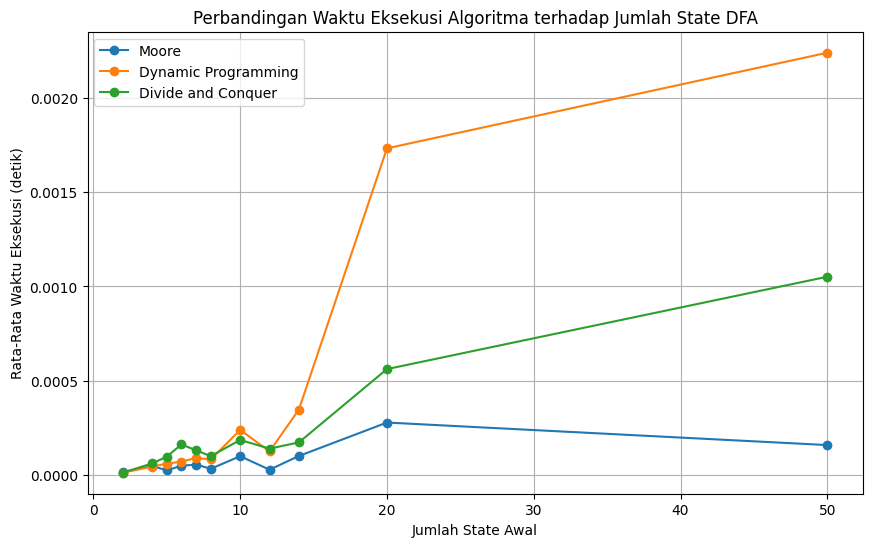

In [ ]:
plt.figure(figsize=(10, 6))

for algorithm_name in results_df["algorithm"].unique():
    subset = size_summary[size_summary["algorithm"] == algorithm_name]
    subset = subset.sort_values("initial_states")

    plt.plot(
        subset["initial_states"],
        subset["avg_time"],
        marker="o",
        label=algorithm_name
    )

plt.xlabel("Jumlah State Awal")
plt.ylabel("Rata-Rata Waktu Eksekusi (detik)")
plt.title("Perbandingan Waktu Eksekusi Algoritma terhadap Jumlah State DFA")
plt.legend()
plt.grid(True)
plt.show()

## 43. Grafik Jumlah State setelah Minimasi

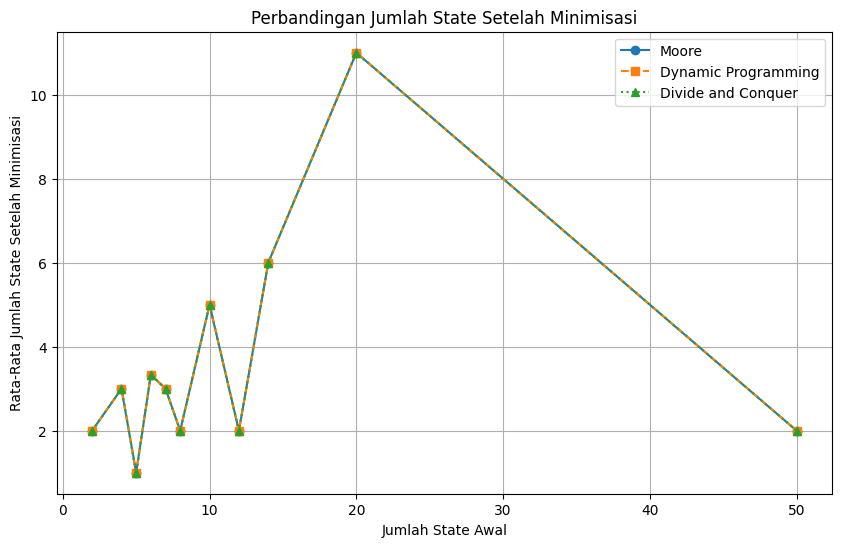

In [ ]:
plt.figure(figsize=(10, 6))

line_styles = {
    "Moore": "-",
    "Dynamic Programming": "--",
    "Divide and Conquer": ":"
}

markers = {
    "Moore": "o",
    "Dynamic Programming": "s",
    "Divide and Conquer": "^"
}

for algorithm_name in results_df["algorithm"].unique():
    subset = size_summary[size_summary["algorithm"] == algorithm_name]
    subset = subset.sort_values("initial_states")

    plt.plot(
        subset["initial_states"],
        subset["avg_minimized_states"],
        marker=markers.get(algorithm_name, "o"),
        linestyle=line_styles.get(algorithm_name, "-"),
        label=algorithm_name
    )

plt.xlabel("Jumlah State Awal")
plt.ylabel("Rata-Rata Jumlah State Setelah Minimisasi")
plt.title("Perbandingan Jumlah State Setelah Minimisasi")
plt.legend()
plt.grid(True)
plt.show()

## 44. Grafik Persentase Reduksi State

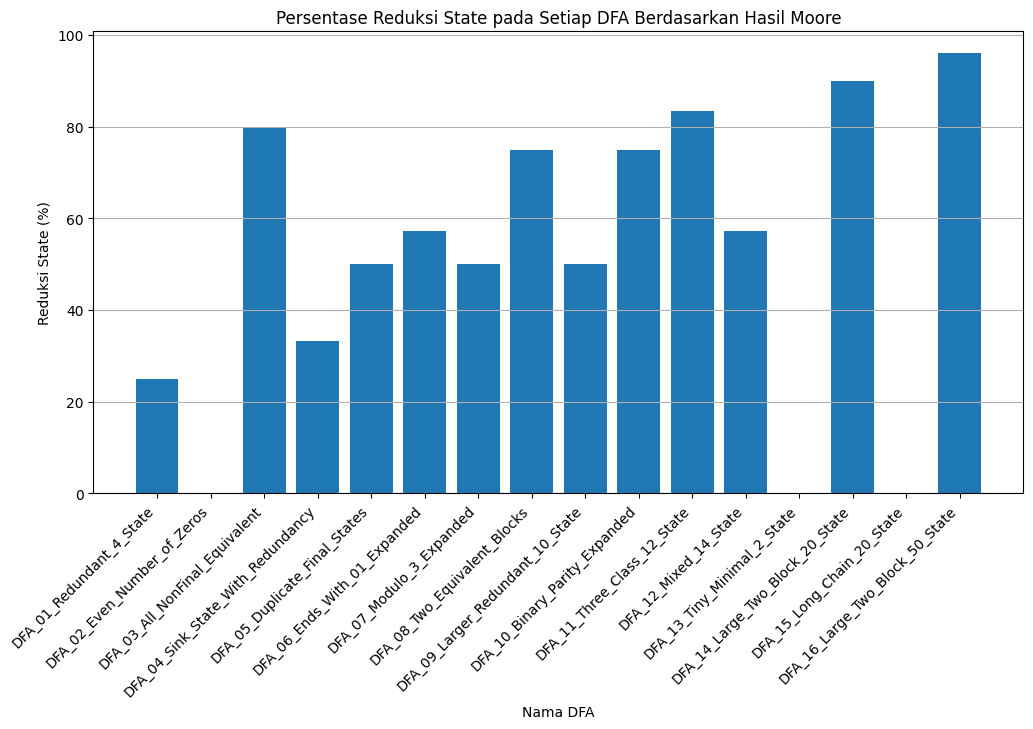

In [ ]:
moore_only = results_df[results_df["algorithm"] == "Moore"].copy()

plt.figure(figsize=(12, 6))

plt.bar(
    moore_only["dfa_name"],
    moore_only["state_reduction_percentage"]
)

plt.xlabel("Nama DFA")
plt.ylabel("Reduksi State (%)")
plt.title("Persentase Reduksi State pada Setiap DFA Berdasarkan Hasil Moore")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

## 45. Grafik Perbandingan Waktu Eksekusi per DFA

algorithm,Divide and Conquer,Dynamic Programming,Moore
dfa_name,,,
DFA_01_Redundant_4_State,0.000060,0.000044,0.000047
DFA_02_Even_Number_of_Zeros,0.000015,0.000015,0.000017
DFA_03_All_NonFinal_Equivalent,0.000096,0.000060,0.000024
DFA_04_Sink_State_With_Redundancy,0.000088,0.000076,0.000059
DFA_05_Duplicate_Final_States,0.000086,0.000072,0.000042
DFA_06_Ends_With_01_Expanded,0.000130,0.000090,0.000054
DFA_07_Modulo_3_Expanded,0.000311,0.000061,0.000044
DFA_08_Two_Equivalent_Blocks,0.000123,0.000100,0.000037
DFA_09_Larger_Redundant_10_State,0.000185,0.000239,0.000099


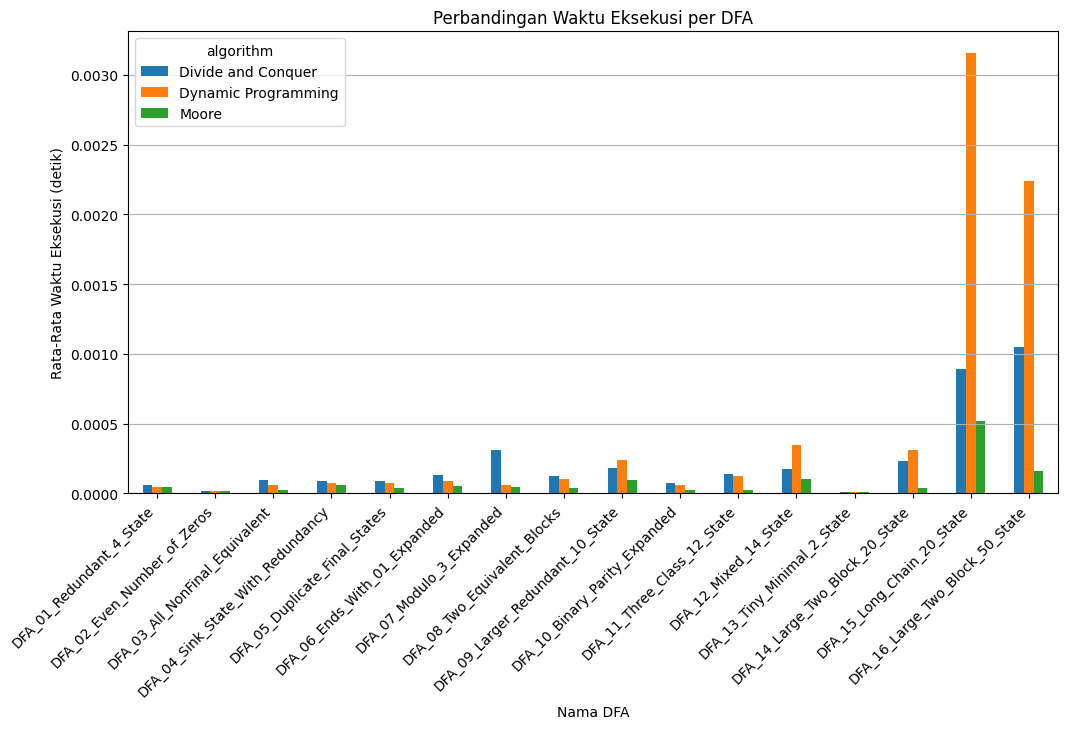

In [ ]:
pivot_time = results_df.pivot_table(
    index="dfa_name",
    columns="algorithm",
    values="avg_execution_time_seconds",
    aggfunc="mean"
)

display(pivot_time)

pivot_time.plot(kind="bar", figsize=(12, 6))

plt.xlabel("Nama DFA")
plt.ylabel("Rata-Rata Waktu Eksekusi (detik)")
plt.title("Perbandingan Waktu Eksekusi per DFA")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

## 46. Export dan Download Hasil Eksperimen (Uncomment dulu)

In [ ]:
# output_file = "hasil_eksperimen_minimisasi_dfa.csv"

# results_df.to_csv(output_file, index=False)

# print(f"Hasil eksperimen berhasil disimpan ke file: {output_file}")

Hasil eksperimen berhasil disimpan ke file: hasil_eksperimen_minimisasi_dfa.csv


In [ ]:
from google.colab import files

files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>